# Terrain Generalization Diagnostics

Run HAPPO through `scripts/diagnose_joint_happo.py` and heuristic approaches through `scripts/diagnose_joint_baseline_strategies.py` for every configured approach-terrain pair, or provide an existing `FILELIST` of diagnostic JSON files to skip rerunning diagnostics. The notebook compares the same core joint performance metrics used in `03_baseline_comparison.ipynb`:

- scout recall: mean and std
- confirmation recall: mean and std
- full-confirm success: rate and binary std
- final confidence: mean and std
- final coverage: mean and std
- scout, confirmation, confidence, and coverage AUC
- time to 100%, 80%, and 50% confirmation recall
- scout-to-confirm latency

Edit the run settings in the first code cell. If `FILELIST` is empty, the notebook runs only missing approach-terrain diagnostics, with up to `MAX_PARALLEL_RUNS` jobs running concurrently. Each output name replaces `malibu` in `MODNAME` with the terrain dictionary key. If `FILELIST` is non-empty, it reads those files directly and does not launch diagnostics.


In [1]:
# Terrain-generalization configuration. MODNAME must contain the source terrain key 'malibu'.
MODNAME = 'uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0'
CKPT = "results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35/models"
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1099
# Sweep over the number of active true survivors in each episode.
# The checkpoint's survivor-slot count is preserved by default. Set SURVIVOR_SLOT_COUNT
# only when running without a checkpoint or when you intentionally want to override it.
STRATEGIES = ['happo', 'ant_colony', 'lawnmower']
COMMS_DROPOUT = 0.0

NSURVIVORS_OBS = 10
NSURVIVORS_MIN = 5
NSURVIVORS_MAX = 10

RUN_DIAGNOSTICS = True
FORCE_RERUN_DIAGNOSTICS = False
# Use 1 for sequential execution; increase carefully because each diagnostic is CPU intensive.
MAX_PARALLEL_RUNS = 2
EXTRA_DIAGNOSTIC_ARGS = []

TERRAIN={
    "malibu": "data/terrain_cache/malibu_creek_1sqkm_256.npz",
    "topanga": "data/terrain_cache/topanga_state_park_1sqkm_256.npz",
    "san_marcos": "data/terrain_cache/san_marcos_foothills_1sqkm_256.npz",
    "aubern": "data/terrain_cache/aubern_sra_1sqkm_256.npz"
}

# Optional: provide existing diagnostic JSON outputs here to skip all diagnostic execution.
FILELIST = []
# FILELIST = [
#      'outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_aubern_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_topanga_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_san_marcos_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/ant_colony_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/ant_colony_uav4_ugv3_area_1sqkm_aubern_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/ant_colony_uav4_ugv3_area_1sqkm_topanga_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/ant_colony_uav4_ugv3_area_1sqkm_san_marcos_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/lawnmower_uav4_ugv3_area_1sqkm_aubern_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/lawnmower_uav4_ugv3_area_1sqkm_topanga_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
#      'outputs/terrain_generalization/lawnmower_uav4_ugv3_area_1sqkm_san_marcos_grid256_steps900_fire_survivors_5_to_10_seeds_1000_1099.json',
# ]

# Optional display labels for FILELIST entries. Leave empty to derive approach and terrain labels.
LABELS = []


In [2]:
import json
import shlex
import subprocess
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import diagnostics

HAPPO_SCRIPT = Path('scripts/diagnose_joint_happo.py')
BASELINE_SCRIPT = Path('scripts/diagnose_joint_baseline_strategies.py')
CWD = Path.cwd().resolve()
if all((CWD / script).is_file() for script in (HAPPO_SCRIPT, BASELINE_SCRIPT)):
    PROJECT_ROOT = CWD
elif all((CWD.parent / script).is_file() for script in (HAPPO_SCRIPT, BASELINE_SCRIPT)):
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path('..').resolve()

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'terrain_generalization'
RESULTS_ROOT = PROJECT_ROOT / 'results/harl_runs/wildfire/wildfire_search/happo'

STRATEGY_LABELS = {
    'happo': 'OmniSearch RL',
    'ant_colony': 'ACO',
    'lawnmower': 'Lawnmower',
    'random_walk': 'Random Walk',
    'random_action': 'Random Action',
    'highest_confidence': 'Highest Confidence',
}
TERRAIN_LABELS = {
    'malibu': 'Malibu Creek State Park',
    'aubern': 'Auburn SRA',
    'topanga': 'Topanga State Park',
    'san_marcos': 'San Marcos Foothills',
}


def _resolve_terrain_cache(path):
    path = Path(path).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    if not path.is_file():
        raise FileNotFoundError(f'Terrain cache not found: {path}')
    return path.resolve()


def _modname_for_terrain(terrain_name):
    if 'malibu' not in MODNAME:
        raise ValueError("MODNAME must contain 'malibu' so it can be replaced by the terrain name")
    return MODNAME.replace('malibu', str(terrain_name))


def _diagnostic_output_paths(strategy, terrain_name):
    strategy_tag = str(strategy).replace('-', '_')
    stem = f'{strategy_tag}_{_modname_for_terrain(terrain_name)}_seeds_{SEED_START}_{SEED_END}'
    return OUTPUT_DIR / f'{stem}.json', OUTPUT_DIR / f'{stem}.png'


def _resolve_json_file(path):
    path = Path(path).expanduser()
    candidates = [path]
    if not path.is_absolute():
        candidates.extend([PROJECT_ROOT / path, PROJECT_ROOT / 'notebooks' / path])
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    return path.resolve() if path.is_absolute() else (PROJECT_ROOT / path).resolve()


In [3]:
def _run_diagnostic_job(strategy, terrain_name, cmd, log_path):
    with log_path.open('w') as log:
        subprocess.run(
            cmd,
            cwd=PROJECT_ROOT,
            check=True,
            stdout=log,
            stderr=subprocess.STDOUT,
        )
    return strategy, terrain_name


if len(STRATEGIES) != len(set(STRATEGIES)):
    raise ValueError('STRATEGIES contains duplicates')
if not TERRAIN:
    raise ValueError('TERRAIN must contain at least one terrain cache')
if int(MAX_PARALLEL_RUNS) < 1:
    raise ValueError('MAX_PARALLEL_RUNS must be at least 1')

if FILELIST:
    JSON_FILES = [_resolve_json_file(path) for path in FILELIST]
    print('Using provided file list; diagnostics will not be run.')
else:
    checkpoint = diagnostics._resolve_checkpoint(CKPT, PROJECT_ROOT, RESULTS_ROOT, MODNAME)
    terrain_caches = {
        name: _resolve_terrain_cache(path)
        for name, path in TERRAIN.items()
    }
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    seeds = [str(seed) for seed in range(SEED_START, SEED_END + 1)]
    JSON_FILES = []
    jobs = []

    for strategy in STRATEGIES:
        for terrain_name, terrain_cache in terrain_caches.items():
            json_output, plots_output = _diagnostic_output_paths(strategy, terrain_name)
            JSON_FILES.append(json_output)
            should_run = RUN_DIAGNOSTICS and (
                FORCE_RERUN_DIAGNOSTICS or not json_output.is_file()
            )
            run_label = f'{strategy}/{terrain_name}'
            if not should_run:
                print(f'Using existing {run_label}:', json_output)
                continue

            cmd = diagnostics._diagnostic_prefix(strategy, checkpoint, PROJECT_ROOT, HAPPO_SCRIPT, BASELINE_SCRIPT )
            cmd.extend([
                '--terrain-cache-path', str(terrain_cache),
                '--steps', str(NSTEPS_PER_EPISODE),
                '--seeds', *seeds,
                '--comms-dropout', str(COMMS_DROPOUT),
                '--n-survivors', str(NSURVIVORS_OBS),
                '--active-survivors-min', str(NSURVIVORS_MIN),
                '--active-survivors-max', str(NSURVIVORS_MAX),
                '--json-output', str(json_output),
                '--plots-output', str(plots_output),
            ])
            cmd.extend(str(arg) for arg in EXTRA_DIAGNOSTIC_ARGS)
            log_path = json_output.with_suffix('.log')
            jobs.append((strategy, terrain_name, cmd, log_path))
            print(f'Queued {run_label}:', shlex.join(cmd))
            print('Log:', log_path)

    if jobs:
        workers = min(int(MAX_PARALLEL_RUNS), len(jobs))
        print(f'Running {len(jobs)} missing diagnostic(s) with {workers} worker(s).')
        with ThreadPoolExecutor(max_workers=workers) as executor:
            futures = {
                executor.submit(
                    _run_diagnostic_job, strategy, terrain_name, cmd, log_path
                ): (strategy, terrain_name, log_path)
                for strategy, terrain_name, cmd, log_path in jobs
            }
            for future in as_completed(futures):
                strategy, terrain_name, log_path = futures[future]
                future.result()
                print(f'Finished {strategy}/{terrain_name}; log={log_path}')

missing = [path for path in JSON_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing diagnostic JSON files:\n' + '\n'.join(str(path) for path in missing))

print(f'Loaded file list: {len(JSON_FILES)} JSON file(s)')
for path in JSON_FILES:
    print(' -', path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path)


Using existing happo/malibu: /Users/aschuetz/Software/capstone/omnisearch/outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
Using existing happo/topanga: /Users/aschuetz/Software/capstone/omnisearch/outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_topanga_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
Using existing happo/san_marcos: /Users/aschuetz/Software/capstone/omnisearch/outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_san_marcos_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
Using existing happo/aubern: /Users/aschuetz/Software/capstone/omnisearch/outputs/terrain_generalization/happo_uav4_ugv3_area_1sqkm_aubern_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
Using existing ant_colony/malibu: /Users/aschuetz/Software/capstone/omnisearch/outputs/terrain_generalization/ant_colony_uav4_ugv3_area_1sqkm_mali

In [4]:
def _run_identity_from_path(path):
    stem = path.stem.lower()
    strategy = next(
        (name for name in STRATEGIES if stem.startswith(f'{name.replace("-", "_")}_')),
        'unknown',
    )
    terrain_name = next(
        (name for name in TERRAIN if f'_{name.lower()}_' in f'_{stem}_'),
        'unknown',
    )
    return strategy, terrain_name


def _label_from_payload(path, payload):
    strategy, terrain_name = _run_identity_from_path(path)
    strategy_label = STRATEGY_LABELS.get(strategy, strategy.replace('_', ' ').title())
    terrain_label = TERRAIN_LABELS.get(terrain_name, terrain_name.replace('_', ' ').title())
    return f'{strategy_label} | {terrain_label}'

if LABELS and len(LABELS) != len(JSON_FILES):
    raise ValueError(f'LABELS has {len(LABELS)} entries, but JSON_FILES has {len(JSON_FILES)} files')

records = []
for file_index, path in enumerate(JSON_FILES):
    payload = json.loads(path.read_text())
    summary = payload.get('summary', {})
    rows = payload.get('rows', [])
    scenario = diagnostics._payload_scenario(payload)
    success_rate = diagnostics._success_rate(summary)
    scout_auc_mean, scout_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_scout_auc',
        'std_scout_auc',
        'scout_auc',
        fallback=lambda row, scenario=scenario: diagnostics._auc_from_first_steps(row, scenario, 'first_scout_steps'),
    )
    confirm_auc_mean, confirm_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_confirm_auc',
        'std_confirm_auc',
        'confirm_auc',
        'confirmation_auc',
        fallback=lambda row, scenario=scenario: diagnostics._auc_from_first_steps(row, scenario, 'first_confirm_steps'),
    )
    coverage_auc_mean, coverage_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_coverage_auc',
        'std_coverage_auc',
        'coverage_auc',
    )
    confidence_auc_mean, confidence_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_confidence_auc',
        'std_confidence_auc',
        'confidence_auc',
    )
    confirm_100 = diagnostics._threshold_time(summary, 'recall_100')
    confirm_080 = diagnostics._threshold_time(summary, 'recall_080')
    confirm_050 = diagnostics._threshold_time(summary, 'recall_050')
    latency_mean, latency_std = diagnostics._latency_stats(summary)
    active_mean, active_std = diagnostics._mean_std(diagnostics._row_values(rows, 'active_survivors', 'survivors'))
    metadata_active_min = diagnostics._scenario_number(scenario, 'active_survivors_min')
    metadata_active_max = diagnostics._scenario_number(scenario, 'active_survivors_max')
    metadata_slots = diagnostics._scenario_number(scenario, 'n_survivors')
    strategy, terrain_name = _run_identity_from_path(path)
    records.append({
        'file': str(path),
        'label': str(LABELS[file_index]) if LABELS else _label_from_payload(path, payload),
        'strategy': strategy,
        'terrain': terrain_name,
        'episodes': diagnostics._summary_value(summary, 'episodes', default=len(rows) if rows else float('nan')),
        'survivor_slots': metadata_slots,
        'active_survivors_min': metadata_active_min,
        'active_survivors_max': metadata_active_max,
        'active_survivors_mean': active_mean,
        'active_survivors_std': active_std,
        'scout_recall_mean': diagnostics._summary_value(summary, 'mean_scout_recall'),
        'scout_recall_std': diagnostics._summary_value(summary, 'std_scout_recall'),
        'confirm_recall_mean': diagnostics._summary_value(summary, 'mean_confirm_recall'),
        'confirm_recall_std': diagnostics._summary_value(summary, 'std_confirm_recall'),
        'success_mean': success_rate,
        'success_std': diagnostics._success_std(summary, success_rate),
        'success_count': diagnostics._summary_value(summary, 'full_confirm_success_count'),
        'final_confidence_mean': diagnostics._summary_value(summary, 'mean_final_confidence'),
        'final_confidence_std': diagnostics._summary_value(summary, 'std_final_confidence'),
        'final_coverage_mean': diagnostics._summary_value(summary, 'mean_final_coverage_fraction'),
        'final_coverage_std': diagnostics._summary_value(summary, 'std_final_coverage_fraction'),
        'scout_auc_mean': scout_auc_mean,
        'scout_auc_std': scout_auc_std,
        'confirm_auc_mean': confirm_auc_mean,
        'confirm_auc_std': confirm_auc_std,
        'coverage_auc_mean': coverage_auc_mean,
        'coverage_auc_std': coverage_auc_std,
        'confidence_auc_mean': confidence_auc_mean,
        'confidence_auc_std': confidence_auc_std,
        'confirm_time_100_mean_s': confirm_100['mean'],
        'confirm_time_100_std_s': confirm_100['std'],
        'confirm_time_100_reached_fraction': confirm_100['reached_fraction'],
        'confirm_time_080_mean_s': confirm_080['mean'],
        'confirm_time_080_std_s': confirm_080['std'],
        'confirm_time_080_reached_fraction': confirm_080['reached_fraction'],
        'confirm_time_050_mean_s': confirm_050['mean'],
        'confirm_time_050_std_s': confirm_050['std'],
        'confirm_time_050_reached_fraction': confirm_050['reached_fraction'],
        'scout_to_confirm_latency_mean_s': latency_mean,
        'scout_to_confirm_latency_std_s': latency_std,
    })

metrics = pd.DataFrame.from_records(records)
metrics


,file,label,strategy,terrain,episodes,survivor_slots,active_survivors_min,active_survivors_max,active_survivors_mean,active_survivors_std,...,confirm_time_100_std_s,confirm_time_100_reached_fraction,confirm_time_080_mean_s,confirm_time_080_std_s,confirm_time_080_reached_fraction,confirm_time_050_mean_s,confirm_time_050_std_s,confirm_time_050_reached_fraction,scout_to_confirm_latency_mean_s,scout_to_confirm_latency_std_s
0,/Users/aschuetz/Software/capstone/omnisearch/o...,OmniSearch RL | Malibu Creek State Park,happo,malibu,100.0,10.0,5.0,10.0,7.38,1.689852,...,271.605578,0.80,965.305263,237.866618,0.95,634.600000,176.910712,1.00,417.553371,267.993664
1,/Users/aschuetz/Software/capstone/omnisearch/o...,OmniSearch RL | Topanga State Park,happo,topanga,100.0,10.0,5.0,10.0,7.38,1.689852,...,251.701574,0.56,1170.966292,272.860521,0.89,761.660000,216.575170,1.00,438.860499,283.257524
2,/Users/aschuetz/Software/capstone/omnisearch/o...,OmniSearch RL | San Marcos Foothills,happo,san_marcos,100.0,10.0,5.0,10.0,7.38,1.689852,...,239.162312,0.44,1184.536585,288.131584,0.82,773.818182,208.106634,0.99,442.914894,268.564385
3,/Users/aschuetz/Software/capstone/omnisearch/o...,OmniSearch RL | Auburn SRA,happo,aubern,100.0,10.0,5.0,10.0,7.38,1.689852,...,225.446240,0.34,1273.825000,257.558963,0.80,884.640000,246.760107,1.00,489.622465,287.922356
4,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO | Malibu Creek State Park,ant_colony,malibu,100.0,10.0,5.0,10.0,7.38,1.689852,...,231.403553,0.72,1126.556701,263.438757,0.97,727.080000,174.827096,1.00,454.505682,305.147012
5,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO | Topanga State Park,ant_colony,topanga,100.0,10.0,5.0,10.0,7.38,1.689852,...,212.781563,0.50,1276.000000,283.870969,0.88,858.840000,210.088968,1.00,466.232489,281.454101
6,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO | San Marcos Foothills,ant_colony,san_marcos,100.0,10.0,5.0,10.0,7.38,1.689852,...,200.092643,0.34,1348.860759,221.759063,0.79,951.220000,240.876382,1.00,462.347962,292.527454
7,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO | Auburn SRA,ant_colony,aubern,100.0,10.0,5.0,10.0,7.38,1.689852,...,219.030887,0.27,1364.750000,267.275771,0.80,968.440000,254.546276,1.00,509.812995,309.520169
8,/Users/aschuetz/Software/capstone/omnisearch/o...,Lawnmower | Malibu Creek State Park,lawnmower,malibu,100.0,10.0,5.0,10.0,7.38,1.689852,...,245.786225,0.68,1185.326531,263.682701,0.98,770.560000,209.270749,1.00,442.182077,304.261194
9,/Users/aschuetz/Software/capstone/omnisearch/o...,Lawnmower | Topanga State Park,lawnmower,topanga,100.0,10.0,5.0,10.0,7.38,1.689852,...,225.060761,0.34,1276.168675,271.185742,0.83,890.800000,219.036801,1.00,429.711214,281.066812


## Compact Table

The table below formats each metric as `mean +/- std` for quick comparison. AUC values are time-integrated performance scores. Confirmation timing values are in minutes and are conditional on episodes that reached the requested confirmation recall threshold; the adjacent reached columns show how many episodes made it that far.


In [5]:
def _pm(mean, std, *, digits=3, suffix=''):
    if pd.isna(mean):
        return 'n/a'
    if pd.isna(std):
        return f'{mean:.{digits}f}{suffix}'
    return f'{mean:.{digits}f} +/- {std:.{digits}f}{suffix}'


def _pct(value):
    if pd.isna(value):
        return 'n/a'
    return f'{100.0 * float(value):.0f}%'


compact = pd.DataFrame({
    'label': metrics['label'],
    'terrain': metrics['terrain'],
    'strategy': metrics['strategy'],
    'episodes': metrics['episodes'].astype('Int64'),
    'survivors': [
        _pm(mean, std)
        for mean, std in zip(metrics['active_survivors_mean'], metrics['active_survivors_std'])
    ],
    'scout recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_recall_mean'], metrics['scout_recall_std'])
    ],
    'confirm recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_recall_mean'], metrics['confirm_recall_std'])
    ],
    'success': [
        _pm(mean, std)
        for mean, std in zip(metrics['success_mean'], metrics['success_std'])
    ],
    'success count': metrics['success_count'].astype('Int64'),
    'final confidence': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_confidence_mean'], metrics['final_confidence_std'])
    ],
    'final coverage': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_coverage_mean'], metrics['final_coverage_std'])
    ],
    'confirm 100% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_100_mean_s'] / 60.0, metrics['confirm_time_100_std_s'] / 60.0)
    ],
    'confirm 100% reached': [_pct(value) for value in metrics['confirm_time_100_reached_fraction']],
    'confirm 80% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_080_mean_s'] / 60.0, metrics['confirm_time_080_std_s'] / 60.0)
    ],
    'confirm 80% reached': [_pct(value) for value in metrics['confirm_time_080_reached_fraction']],
    'confirm 50% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_050_mean_s'] / 60.0, metrics['confirm_time_050_std_s'] / 60.0)
    ],
    'confirm 50% reached': [_pct(value) for value in metrics['confirm_time_050_reached_fraction']],
    'scout-to-confirm latency (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['scout_to_confirm_latency_mean_s'] / 60.0, metrics['scout_to_confirm_latency_std_s'] / 60.0)
    ],
    'scout AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_auc_mean'], metrics['scout_auc_std'])
    ],
    'confirm AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_auc_mean'], metrics['confirm_auc_std'])
    ],
    'confidence AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confidence_auc_mean'], metrics['confidence_auc_std'])
    ],
    'coverage AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['coverage_auc_mean'], metrics['coverage_auc_std'])
    ],
}).set_index('label')

compact


,terrain,strategy,episodes,survivors,scout recall,confirm recall,success,success count,final confidence,final coverage,...,confirm 100% reached,confirm 80% time (min),confirm 80% reached,confirm 50% time (min),confirm 50% reached,scout-to-confirm latency (min),scout AUC,confirm AUC,confidence AUC,coverage AUC
label,,,,,,,,,,,,,,,,,,,,,
OmniSearch RL | Malibu Creek State Park,malibu,happo,100,7.380 +/- 1.690,0.986 +/- 0.060,0.962 +/- 0.085,0.800 +/- 0.400,80,0.987 +/- 0.021,0.993 +/- 0.017,...,80%,16.1 +/- 4.0 min,95%,10.6 +/- 2.9 min,100%,7.0 +/- 4.5 min,0.832 +/- 0.079,0.599 +/- 0.083,0.839 +/- 0.017,0.862 +/- 0.015
OmniSearch RL | Topanga State Park,topanga,happo,100,7.380 +/- 1.690,0.972 +/- 0.059,0.926 +/- 0.098,0.560 +/- 0.496,56,0.976 +/- 0.017,0.986 +/- 0.013,...,56%,19.5 +/- 4.5 min,89%,12.7 +/- 3.6 min,100%,7.3 +/- 4.7 min,0.767 +/- 0.082,0.517 +/- 0.100,0.781 +/- 0.012,0.812 +/- 0.012
OmniSearch RL | San Marcos Foothills,san_marcos,happo,100,7.380 +/- 1.690,0.955 +/- 0.089,0.888 +/- 0.124,0.440 +/- 0.496,44,0.964 +/- 0.036,0.978 +/- 0.029,...,44%,19.7 +/- 4.8 min,82%,12.9 +/- 3.5 min,99%,7.4 +/- 4.5 min,0.761 +/- 0.093,0.503 +/- 0.099,0.759 +/- 0.021,0.795 +/- 0.018
OmniSearch RL | Auburn SRA,aubern,happo,100,7.380 +/- 1.690,0.958 +/- 0.073,0.871 +/- 0.116,0.340 +/- 0.474,34,0.961 +/- 0.026,0.976 +/- 0.020,...,34%,21.2 +/- 4.3 min,80%,14.7 +/- 4.1 min,100%,8.2 +/- 4.8 min,0.735 +/- 0.089,0.461 +/- 0.099,0.744 +/- 0.016,0.780 +/- 0.015
ACO | Malibu Creek State Park,malibu,ant_colony,100,7.380 +/- 1.690,0.995 +/- 0.027,0.957 +/- 0.073,0.720 +/- 0.449,72,0.994 +/- 0.002,1.000 +/- 0.000,...,72%,18.8 +/- 4.4 min,97%,12.1 +/- 2.9 min,100%,7.6 +/- 5.1 min,0.813 +/- 0.058,0.545 +/- 0.082,0.814 +/- 0.010,0.831 +/- 0.011
ACO | Topanga State Park,topanga,ant_colony,100,7.380 +/- 1.690,0.987 +/- 0.043,0.909 +/- 0.112,0.500 +/- 0.500,50,0.985 +/- 0.003,0.996 +/- 0.001,...,50%,21.3 +/- 4.7 min,88%,14.3 +/- 3.5 min,100%,7.8 +/- 4.7 min,0.754 +/- 0.070,0.471 +/- 0.088,0.754 +/- 0.012,0.778 +/- 0.012
ACO | San Marcos Foothills,san_marcos,ant_colony,100,7.380 +/- 1.690,0.991 +/- 0.035,0.865 +/- 0.126,0.340 +/- 0.474,34,0.989 +/- 0.002,1.000 +/- 0.000,...,34%,22.5 +/- 3.7 min,79%,15.9 +/- 4.0 min,100%,7.7 +/- 4.9 min,0.732 +/- 0.064,0.431 +/- 0.087,0.733 +/- 0.010,0.758 +/- 0.011
ACO | Auburn SRA,aubern,ant_colony,100,7.380 +/- 1.690,0.984 +/- 0.049,0.853 +/- 0.123,0.270 +/- 0.444,27,0.987 +/- 0.002,0.999 +/- 0.000,...,27%,22.7 +/- 4.5 min,80%,16.1 +/- 4.2 min,100%,8.5 +/- 5.2 min,0.730 +/- 0.079,0.416 +/- 0.099,0.725 +/- 0.012,0.751 +/- 0.013
Lawnmower | Malibu Creek State Park,malibu,lawnmower,100,7.380 +/- 1.690,1.000 +/- 0.000,0.953 +/- 0.076,0.680 +/- 0.466,68,1.000 +/- 0.000,1.000 +/- 0.000,...,68%,19.8 +/- 4.4 min,98%,12.8 +/- 3.5 min,100%,7.4 +/- 5.1 min,0.791 +/- 0.060,0.527 +/- 0.094,0.792 +/- 0.004,0.806 +/- 0.004


## Plots

The two paper-style grouped-bar plots show HAPPO only: success plus time-integrated AUC metrics first, then confirmation timing in minutes. The final graph compares confirmation AUC across terrains with one line per approach.


In [6]:
import omnisearch_plotting as plot

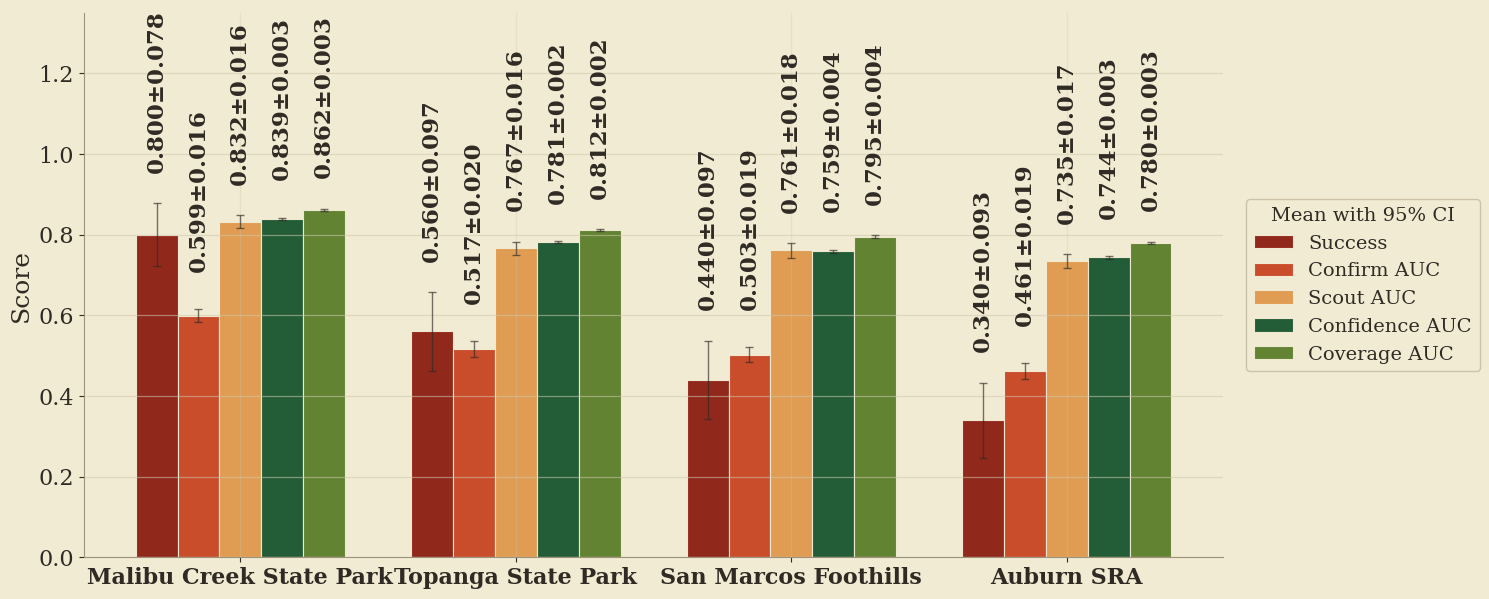

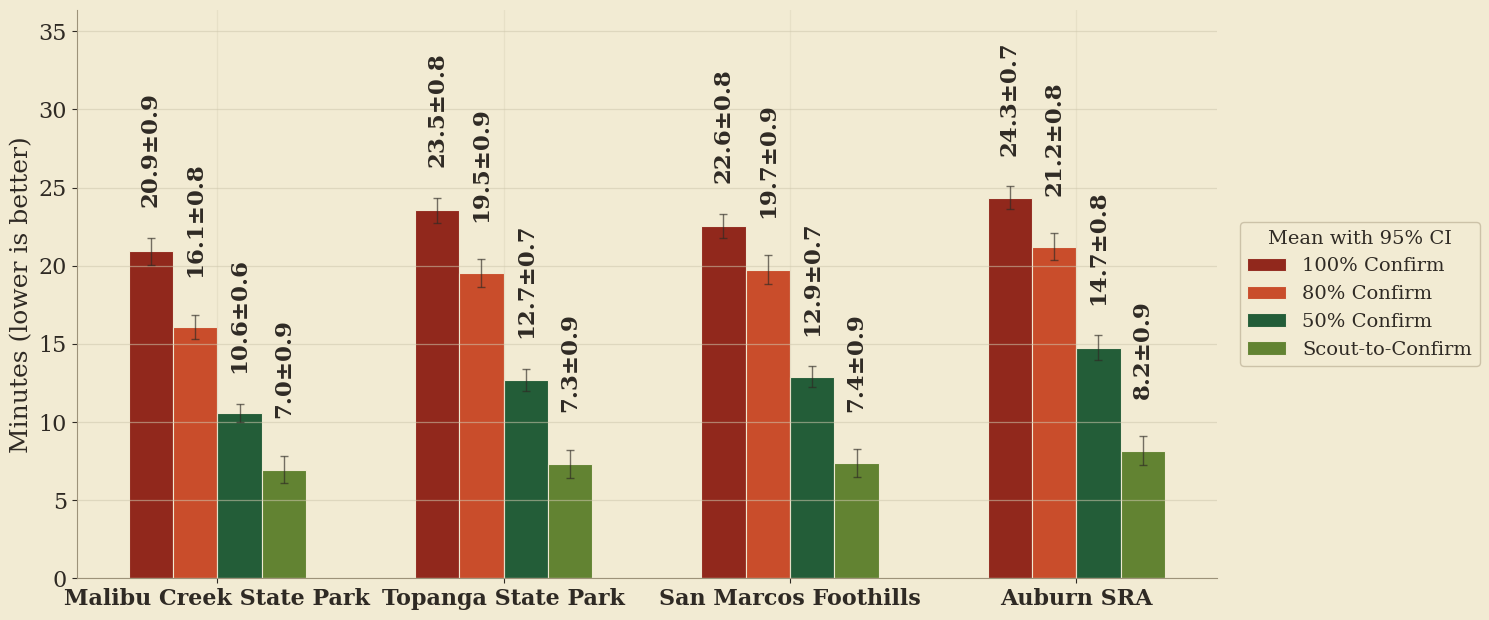

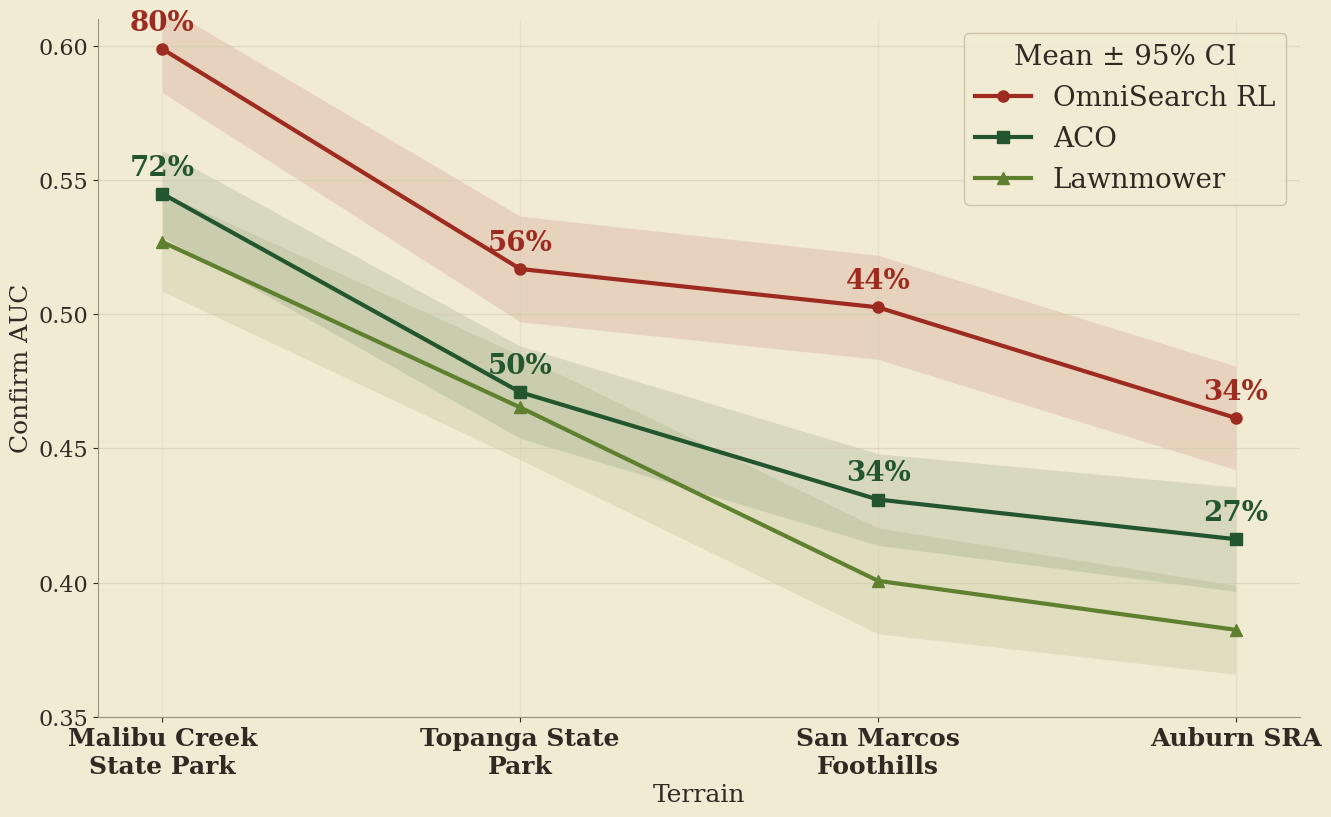

In [7]:
plot_df = metrics.copy().reset_index(drop=True)
for prefix in (
    'confirm_time_100',
    'confirm_time_080',
    'confirm_time_050',
    'scout_to_confirm_latency',
):
    plot_df[f'{prefix}_mean_min'] = pd.to_numeric(plot_df[f'{prefix}_mean_s'], errors='coerce') / 60.0
    plot_df[f'{prefix}_std_min'] = pd.to_numeric(plot_df[f'{prefix}_std_s'], errors='coerce') / 60.0

happo_plot_df = plot_df.loc[
    plot_df['strategy'].astype(str).str.replace('-', '_').eq('happo')
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(max(15, len(plot_df) * 1.1), 6.3), facecolor=plot.PAPER_BG)
plot._plot_metrics_bars(
    ax,
    happo_plot_df,
    plot.AUC_METRIC_SPECS,
    title='Omnisearch RL Success And Time-Integrated Performance (AUC)',
    ylabel='Score',
    y_limit=(0.0, 1.35),
    label_digits=3,
    x_labels='terrain',
)
fig.tight_layout()
plt.savefig('../outputs/figures/terrain_performance.png')
plt.show()

fig, ax = plt.subplots(figsize=(max(15, len(plot_df) * 1.1), 6.3), facecolor=plot.PAPER_BG)
plot._plot_metrics_bars(
    ax,
    happo_plot_df,
    plot.TIME_METRIC_SPECS,
    title='Omnisearch RL Confirmation Timing',
    ylabel='Minutes (lower is better)',
    mean_suffix='_mean_min',
    std_suffix='_std_min',
    label_suffix='',
    label_digits=1,
    x_labels='terrain',
)
fig.tight_layout()
plt.savefig('../outputs/figures/terrain_timing.png')
plt.show()

fig, ax = plt.subplots(figsize=(13.5, 8.3), facecolor=plot.PAPER_BG)
plot._plot_confirm_auc_curve(ax, plot_df, title='Confirmation AUC Across Terrains',x_title='Terrain', x_label='terrain', print_percentage=["happo","ant_colony"],y_limit=[0.35,0.61])
fig.tight_layout()
plt.savefig('../outputs/figures/terrain_baseline_comparison.png')
plt.show()
